# MODELING

For xG modeling, the best models are once that progressively answer “How much predictive power comes from nonlinear interactions beyond classical geometry?”

As such, I will focus on 5 models, namely: 
Logistic Regression, Random Forest(for a Nonlinear baseline), XGBoost(for a Strong tabular benchmark), CatBoost(Categorical-feature benchmark), and a simple CNN.


In [1]:
import pandas as pd

df = pd.read_csv('~/Desktop/Football_Stats/xG/shots.csv')
df.head()

,location,shot_aerial_won,shot_first_time,shot_statsbomb_xg,under_pressure,shot_open_goal,shot_follows_dribble,goal,shot_body_part_Head,shot_body_part_Left Foot,...,shot_technique_Overhead Kick,shot_technique_Volley,shot_type_Corner,shot_type_Free Kick,shot_type_Open Play,shot_type_Penalty,x,y,distance,angle
0,"[107.1, 26.6]",0,0,0.020838,0,0,0,0,0,0,...,0,0,0,0,1,0,107.1,26.6,18.600269,17.367371
1,"[113.7, 54.0]",0,0,0.034462,0,0,0,0,0,0,...,0,0,0,0,1,0,113.7,54.0,15.352199,12.920882
2,"[115.7, 50.5]",0,1,0.035481,1,0,0,0,0,1,...,1,0,0,0,1,0,115.7,50.5,11.346365,16.968355
3,"[113.9, 38.6]",0,0,0.383711,0,0,0,0,1,0,...,0,0,0,0,1,0,113.9,38.6,6.258594,64.601862
4,"[96.7, 47.2]",0,0,0.036740,0,0,0,0,0,0,...,0,0,0,0,1,0,96.7,47.2,24.387087,17.852948


In [2]:
df.columns

Index(['location', 'shot_aerial_won', 'shot_first_time', 'shot_statsbomb_xg',
       'under_pressure', 'shot_open_goal', 'shot_follows_dribble', 'goal',
       'shot_body_part_Head', 'shot_body_part_Left Foot',
       'shot_body_part_Other', 'shot_body_part_Right Foot',
       'shot_technique_Backheel', 'shot_technique_Diving Header',
       'shot_technique_Half Volley', 'shot_technique_Lob',
       'shot_technique_Normal', 'shot_technique_Overhead Kick',
       'shot_technique_Volley', 'shot_type_Corner', 'shot_type_Free Kick',
       'shot_type_Open Play', 'shot_type_Penalty', 'x', 'y', 'distance',
       'angle'],
      dtype='object')

In [3]:
y = df['goal']
X = df.drop(['goal', 'shot_statsbomb_xg'], axis=1)

print(f"{X.shape}, {y.shape}")

(9908, 25), (9908,)


In [4]:
X.head()

,location,shot_aerial_won,shot_first_time,under_pressure,shot_open_goal,shot_follows_dribble,shot_body_part_Head,shot_body_part_Left Foot,shot_body_part_Other,shot_body_part_Right Foot,...,shot_technique_Overhead Kick,shot_technique_Volley,shot_type_Corner,shot_type_Free Kick,shot_type_Open Play,shot_type_Penalty,x,y,distance,angle
0,"[107.1, 26.6]",0,0,0,0,0,0,0,0,1,...,0,0,0,0,1,0,107.1,26.6,18.600269,17.367371
1,"[113.7, 54.0]",0,0,0,0,0,0,0,0,1,...,0,0,0,0,1,0,113.7,54.0,15.352199,12.920882
2,"[115.7, 50.5]",0,1,1,0,0,0,1,0,0,...,1,0,0,0,1,0,115.7,50.5,11.346365,16.968355
3,"[113.9, 38.6]",0,0,0,0,0,1,0,0,0,...,0,0,0,0,1,0,113.9,38.6,6.258594,64.601862
4,"[96.7, 47.2]",0,0,0,0,0,0,0,0,1,...,0,0,0,0,1,0,96.7,47.2,24.387087,17.852948


Run the following code if you don't have scikit-learn installed in your environment

In [5]:
# %conda install -c conda-forge scikit-learn

In [6]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
X_train.head()

,location,shot_aerial_won,shot_first_time,under_pressure,shot_open_goal,shot_follows_dribble,shot_body_part_Head,shot_body_part_Left Foot,shot_body_part_Other,shot_body_part_Right Foot,...,shot_technique_Overhead Kick,shot_technique_Volley,shot_type_Corner,shot_type_Free Kick,shot_type_Open Play,shot_type_Penalty,x,y,distance,angle
3333,"[112.8, 44.5]",0,0,1,0,0,0,0,0,1,...,0,0,0,0,1,0,112.8,44.5,8.490583,45.760942
2166,"[99.1, 46.2]",0,1,0,0,0,0,0,0,1,...,0,0,0,0,1,0,99.1,46.2,21.800229,20.005141
8009,"[103.6, 21.5]",0,0,0,0,0,0,0,0,1,...,0,0,0,0,1,0,103.6,21.5,24.722662,12.430720
8299,"[90.9, 32.2]",0,0,0,0,0,0,0,0,1,...,0,0,0,0,1,0,90.9,32.2,30.127230,14.632645
2825,"[112.8, 45.0]",0,0,1,0,0,0,1,0,0,...,0,0,0,0,1,0,112.8,45.0,8.765843,43.433029


In [7]:
X_train.drop(['location','x','y'], axis=1, inplace=True)
cordinates = X_test[['x', 'y']] # for model visualizations
X_test.drop(['location','x','y'], axis=1, inplace=True)

X_train.head()

,shot_aerial_won,shot_first_time,under_pressure,shot_open_goal,shot_follows_dribble,shot_body_part_Head,shot_body_part_Left Foot,shot_body_part_Other,shot_body_part_Right Foot,shot_technique_Backheel,...,shot_technique_Lob,shot_technique_Normal,shot_technique_Overhead Kick,shot_technique_Volley,shot_type_Corner,shot_type_Free Kick,shot_type_Open Play,shot_type_Penalty,distance,angle
3333,0,0,1,0,0,0,0,0,1,0,...,0,0,0,0,0,0,1,0,8.490583,45.760942
2166,0,1,0,0,0,0,0,0,1,0,...,0,0,0,0,0,0,1,0,21.800229,20.005141
8009,0,0,0,0,0,0,0,0,1,0,...,0,1,0,0,0,0,1,0,24.722662,12.430720
8299,0,0,0,0,0,0,0,0,1,0,...,0,1,0,0,0,0,1,0,30.127230,14.632645
2825,0,0,1,0,0,0,1,0,0,0,...,0,1,0,0,0,0,1,0,8.765843,43.433029


In [8]:
cordinates.shape

(2973, 2)

## LOGISTIC REGRESSION

In [9]:
from sklearn.linear_model import LogisticRegression

logistic_regressor = LogisticRegression(max_iter=1000)
logistic_regressor.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [10]:
y_log= logistic_regressor.predict_proba(X_test)[:,1]
y_log[:10]

array([0.01658181, 0.05983612, 0.07854029, 0.3793527 , 0.02164615,
       0.49893363, 0.31535138, 0.02138289, 0.10913211, 0.17576026])

In [11]:
log_df = X_test.copy()
log_df['xG'] = y_log
log_df.iloc[830]

shot_aerial_won                  0.000000
shot_first_time                  1.000000
under_pressure                   0.000000
shot_open_goal                   0.000000
shot_follows_dribble             0.000000
shot_body_part_Head              0.000000
shot_body_part_Left Foot         0.000000
shot_body_part_Other             0.000000
shot_body_part_Right Foot        1.000000
shot_technique_Backheel          0.000000
shot_technique_Diving Header     0.000000
shot_technique_Half Volley       0.000000
shot_technique_Lob               0.000000
shot_technique_Normal            1.000000
shot_technique_Overhead Kick     0.000000
shot_technique_Volley            0.000000
shot_type_Corner                 0.000000
shot_type_Free Kick              0.000000
shot_type_Open Play              1.000000
shot_type_Penalty                0.000000
distance                        13.807969
angle                           31.730334
xG                               0.192964
Name: 447, dtype: float64

In [12]:
log_df.iloc[100]

shot_aerial_won                   0.000000
shot_first_time                   0.000000
under_pressure                    0.000000
shot_open_goal                    1.000000
shot_follows_dribble              0.000000
shot_body_part_Head               0.000000
shot_body_part_Left Foot          0.000000
shot_body_part_Other              0.000000
shot_body_part_Right Foot         1.000000
shot_technique_Backheel           0.000000
shot_technique_Diving Header      0.000000
shot_technique_Half Volley        0.000000
shot_technique_Lob                0.000000
shot_technique_Normal             1.000000
shot_technique_Overhead Kick      0.000000
shot_technique_Volley             0.000000
shot_type_Corner                  0.000000
shot_type_Free Kick               0.000000
shot_type_Open Play               1.000000
shot_type_Penalty                 0.000000
distance                          2.817801
angle                           127.775684
xG                                0.914436
Name: 39, d

## RANDOM FOREST

In [13]:
from sklearn.ensemble import RandomForestClassifier

random_forest = RandomForestClassifier(n_estimators=100, random_state=42)
# try tuning parameters
# compre overall accuracy 
random_forest.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [14]:
y_rf = random_forest.predict_proba(X_test)[:,1]
y_rf[:10]

array([0.  , 0.03, 0.  , 0.54, 0.  , 0.15, 0.52, 0.05, 0.02, 0.09])

In [15]:
rf_df = pd.DataFrame()
rf_df['Goal'] = y_test.copy()
rf_df['xG'] = y_rf
rf_df.iloc[830]

Goal    0.00
xG      0.09
Name: 447, dtype: float64

In [16]:
rf_df.iloc[100]

Goal    1.00
xG      0.94
Name: 39, dtype: float64

## XGBOOST

Run the following code if you don't have xgboost installed in your environment

In [17]:
# % conda install -c conda-forge xgboost

In [18]:
import xgboost as xgb

In [19]:
xgb = xgb.XGBClassifier(
    n_estimators=100,
    max_depth=3,
    learning_rate=0.1,
    objective='binary:logistic'
)

xgb.fit(X_train, y_train)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [20]:
y_xgb = xgb.predict_proba(X_test)[:,1]

In [21]:
xgb_df = pd.DataFrame()
xgb_df['Goal'] = y_test.copy()
xgb_df['xG'] = y_rf
xgb_df.iloc[830]

Goal    0.00
xG      0.09
Name: 447, dtype: float64

In [22]:
xgb_df.iloc[100]

Goal    1.00
xG      0.94
Name: 39, dtype: float64

## CATBOOST

Run the following code if you don't have CatBoost installed in your environment

In [23]:
# %conda install -c conda-forge catboost

In [24]:
from catboost import CatBoostClassifier

In [25]:
catBoost = CatBoostClassifier(
    iterations=100,
    learning_rate=0.1,
    depth=6,
    verbose=10
)

catBoost.fit(X_train, y_train)

0:	learn: 0.5925481	total: 69.7ms	remaining: 6.9s
10:	learn: 0.2973984	total: 85.2ms	remaining: 689ms
20:	learn: 0.2688631	total: 101ms	remaining: 379ms
30:	learn: 0.2618012	total: 117ms	remaining: 259ms
40:	learn: 0.2582310	total: 132ms	remaining: 190ms
50:	learn: 0.2566930	total: 146ms	remaining: 141ms
60:	learn: 0.2545667	total: 162ms	remaining: 104ms
70:	learn: 0.2517031	total: 177ms	remaining: 72.4ms
80:	learn: 0.2492420	total: 192ms	remaining: 45ms
90:	learn: 0.2462555	total: 208ms	remaining: 20.6ms
99:	learn: 0.2441766	total: 220ms	remaining: 0us


In [26]:
y_cat = catBoost.predict_proba(X_test)[:,1]

In [27]:
cat_df = pd.DataFrame()
cat_df['Goal'] = y_test.copy()
cat_df['xG'] = y_cat
cat_df.iloc[830]

Goal    0.000000
xG      0.242879
Name: 447, dtype: float64

In [28]:
cat_df.iloc[100]

Goal    1.000000
xG      0.956043
Name: 39, dtype: float64

# MODEL EVAULATION

For Logistic Regression

In [29]:
log_df.sort_values(by='xG', ascending=False).head()

,shot_aerial_won,shot_first_time,under_pressure,shot_open_goal,shot_follows_dribble,shot_body_part_Head,shot_body_part_Left Foot,shot_body_part_Other,shot_body_part_Right Foot,shot_technique_Backheel,...,shot_technique_Normal,shot_technique_Overhead Kick,shot_technique_Volley,shot_type_Corner,shot_type_Free Kick,shot_type_Open Play,shot_type_Penalty,distance,angle,xG
1832,0,0,0,1,0,0,0,1,0,0,...,1,0,0,0,0,1,0,1.769181,143.279979,0.936936
1175,0,1,0,1,0,0,0,1,0,0,...,1,0,0,0,0,1,0,2.267157,128.608394,0.920776
9725,0,0,0,1,0,0,0,1,0,0,...,1,0,0,0,0,1,0,2.641969,130.935351,0.915040
39,0,0,0,1,0,0,0,0,1,0,...,1,0,0,0,0,1,0,2.817801,127.775684,0.914436
9284,0,0,0,1,0,0,0,1,0,0,...,1,0,0,0,0,1,0,2.983287,115.037526,0.887217


In [30]:
from sklearn.metrics import log_loss, roc_auc_score, brier_score_loss, accuracy_score

print(f"Log Loss: {log_loss(y_test, y_log):.3f}\nROC_AUC Score: {roc_auc_score(y_test, y_log):.3f}\nBrier Score: {brier_score_loss(y_test, y_log):.3f}")

Log Loss: 0.265
ROC_AUC Score: 0.783
Brier Score: 0.074


For Random Forest

In [31]:
print(f"Log Loss: {log_loss(y_test, y_rf):.3f}\nROC_AUC Score: {roc_auc_score(y_test, y_rf):.3f}\nBrier Score: {brier_score_loss(y_test, y_rf):.3f}")

Log Loss: 0.660
ROC_AUC Score: 0.727
Brier Score: 0.086


For XGBoost

In [32]:
print(f"Log Loss: {log_loss(y_test, y_xgb):.3f}\nROC_AUC Score: {roc_auc_score(y_test, y_xgb):.3f}\nBrier Score: {brier_score_loss(y_test, y_xgb):.3f}")

Log Loss: 0.264
ROC_AUC Score: 0.788
Brier Score: 0.074


For CatBoost

In [33]:
print(f"Log Loss: {log_loss(y_test, y_cat):.3f}\nROC_AUC Score: {roc_auc_score(y_test, y_cat):.3f}\nBrier Score: {brier_score_loss(y_test, y_cat):.3f}")

Log Loss: 0.264
ROC_AUC Score: 0.786
Brier Score: 0.074


TABULATING DATA

Calibration Curve

In [34]:
# %conda install -c conda-forge matplotlib

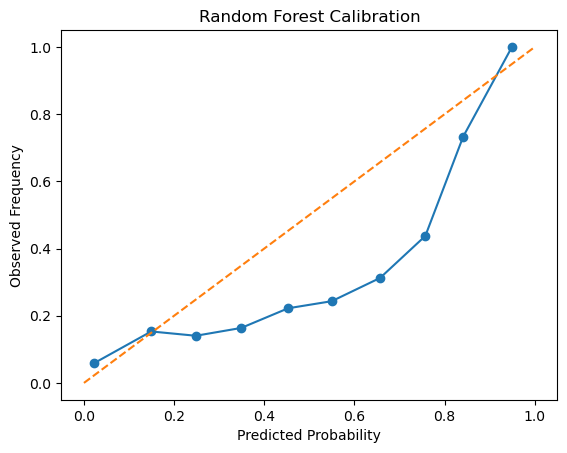

In [35]:
from sklearn.calibration import calibration_curve
import matplotlib.pyplot as plt

prob_rf, prob_pred = calibration_curve(
    y_test,
    y_rf,
    n_bins=10
)

plt.plot(prob_pred, prob_rf, marker='o')
plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel("Predicted Probability")
plt.ylabel("Observed Frequency")
plt.title("Random Forest Calibration")
plt.show()

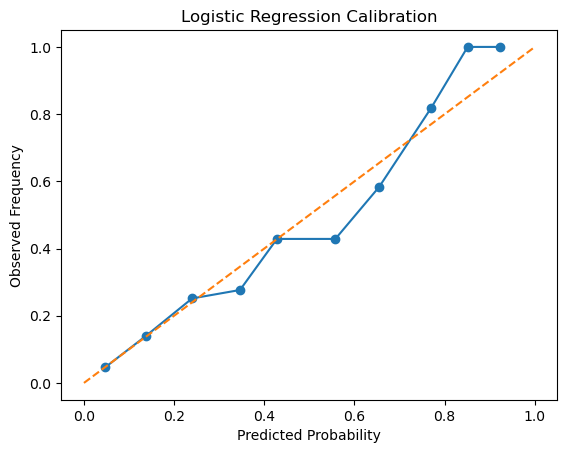

In [43]:
prob_rf, prob_pred = calibration_curve(
    y_test,
    y_log,
    n_bins=10
)

plt.plot(prob_pred, prob_rf, marker='o')
plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel("Predicted Probability")
plt.ylabel("Observed Frequency")
plt.title("Logistic Regression Calibration")
plt.show()

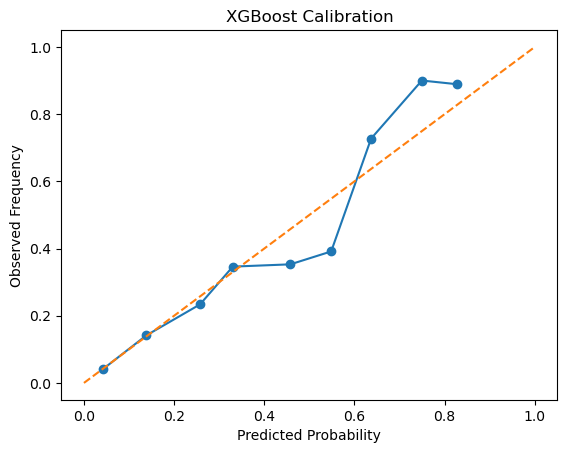

In [37]:
prob_xgb, prob_pred = calibration_curve(
    y_test,
    y_xgb,
    n_bins=10
)

plt.plot(prob_pred, prob_xgb, marker='o')
plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel("Predicted Probability")
plt.ylabel("Observed Frequency")
plt.title("XGBoost Calibration")
plt.show()

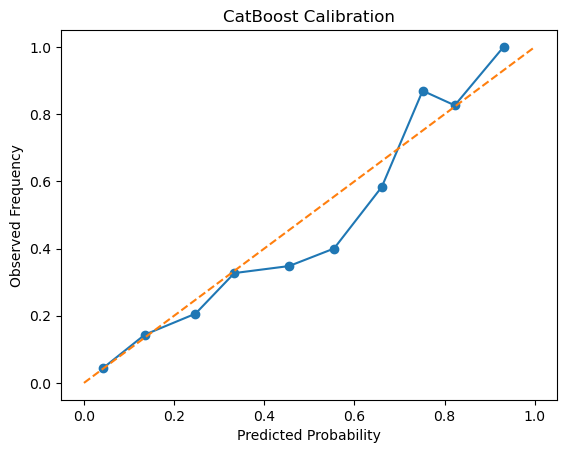

In [38]:
prob_cat, prob_pred = calibration_curve(
    y_test,
    y_cat,
    n_bins=10
)

plt.plot(prob_pred, prob_cat, marker='o')
plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel("Predicted Probability")
plt.ylabel("Observed Frequency")
plt.title("CatBoost Calibration")
plt.show()

## Feature Importance

In [39]:
importance = pd.Series(
    random_forest.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

print(importance)

angle                           0.432809
distance                        0.422513
shot_type_Penalty               0.021310
shot_open_goal                  0.019422
under_pressure                  0.013613
shot_first_time                 0.011861
shot_technique_Normal           0.010691
shot_type_Open Play             0.010449
shot_body_part_Right Foot       0.009806
shot_body_part_Head             0.009046
shot_body_part_Left Foot        0.006672
shot_technique_Half Volley      0.006189
shot_technique_Volley           0.005506
shot_aerial_won                 0.005413
shot_type_Free Kick             0.002986
shot_technique_Lob              0.002832
shot_technique_Backheel         0.002189
shot_body_part_Other            0.001778
shot_technique_Diving Header    0.001708
shot_technique_Overhead Kick    0.001547
shot_follows_dribble            0.000903
shot_type_Corner                0.000759
dtype: float64


# MODEL VISUALIZATIONS

In [40]:
from mplsoccer import Pitch
from matplotlib.colors import LinearSegmentedColormap

pitch = Pitch(pitch_type='opta')
colors = ['red', 'yellow', 'green']
cmap = LinearSegmentedColormap.from_list('my_colormap', colors)
sc = pitch.scatter

In [41]:
# import numpy as np

# dataframes = {
#     'Logistic Regression': log_df,
#     'Random Forest': rf_df,
#     'XGBoost': xgb_df,
#     'CatBoost': cat_df
# }

# for name, df in dataframes.items():

#     fig, ax = pitch.draw(figsize=(10,8))
#     sc = pitch.scatter(
#         cordinates['x'], cordinates['y'], c=df['xG'],
#         cmap=cmap, edgecolors='black', linewidth=0.5, s=100, ax=ax
#     )

#     cbar = plt.colorbar(sc, ax=ax, orientation='vertical', fraction=0.02, pad=0.02)
#     cbar.set_label(f'{name} xG Probability')

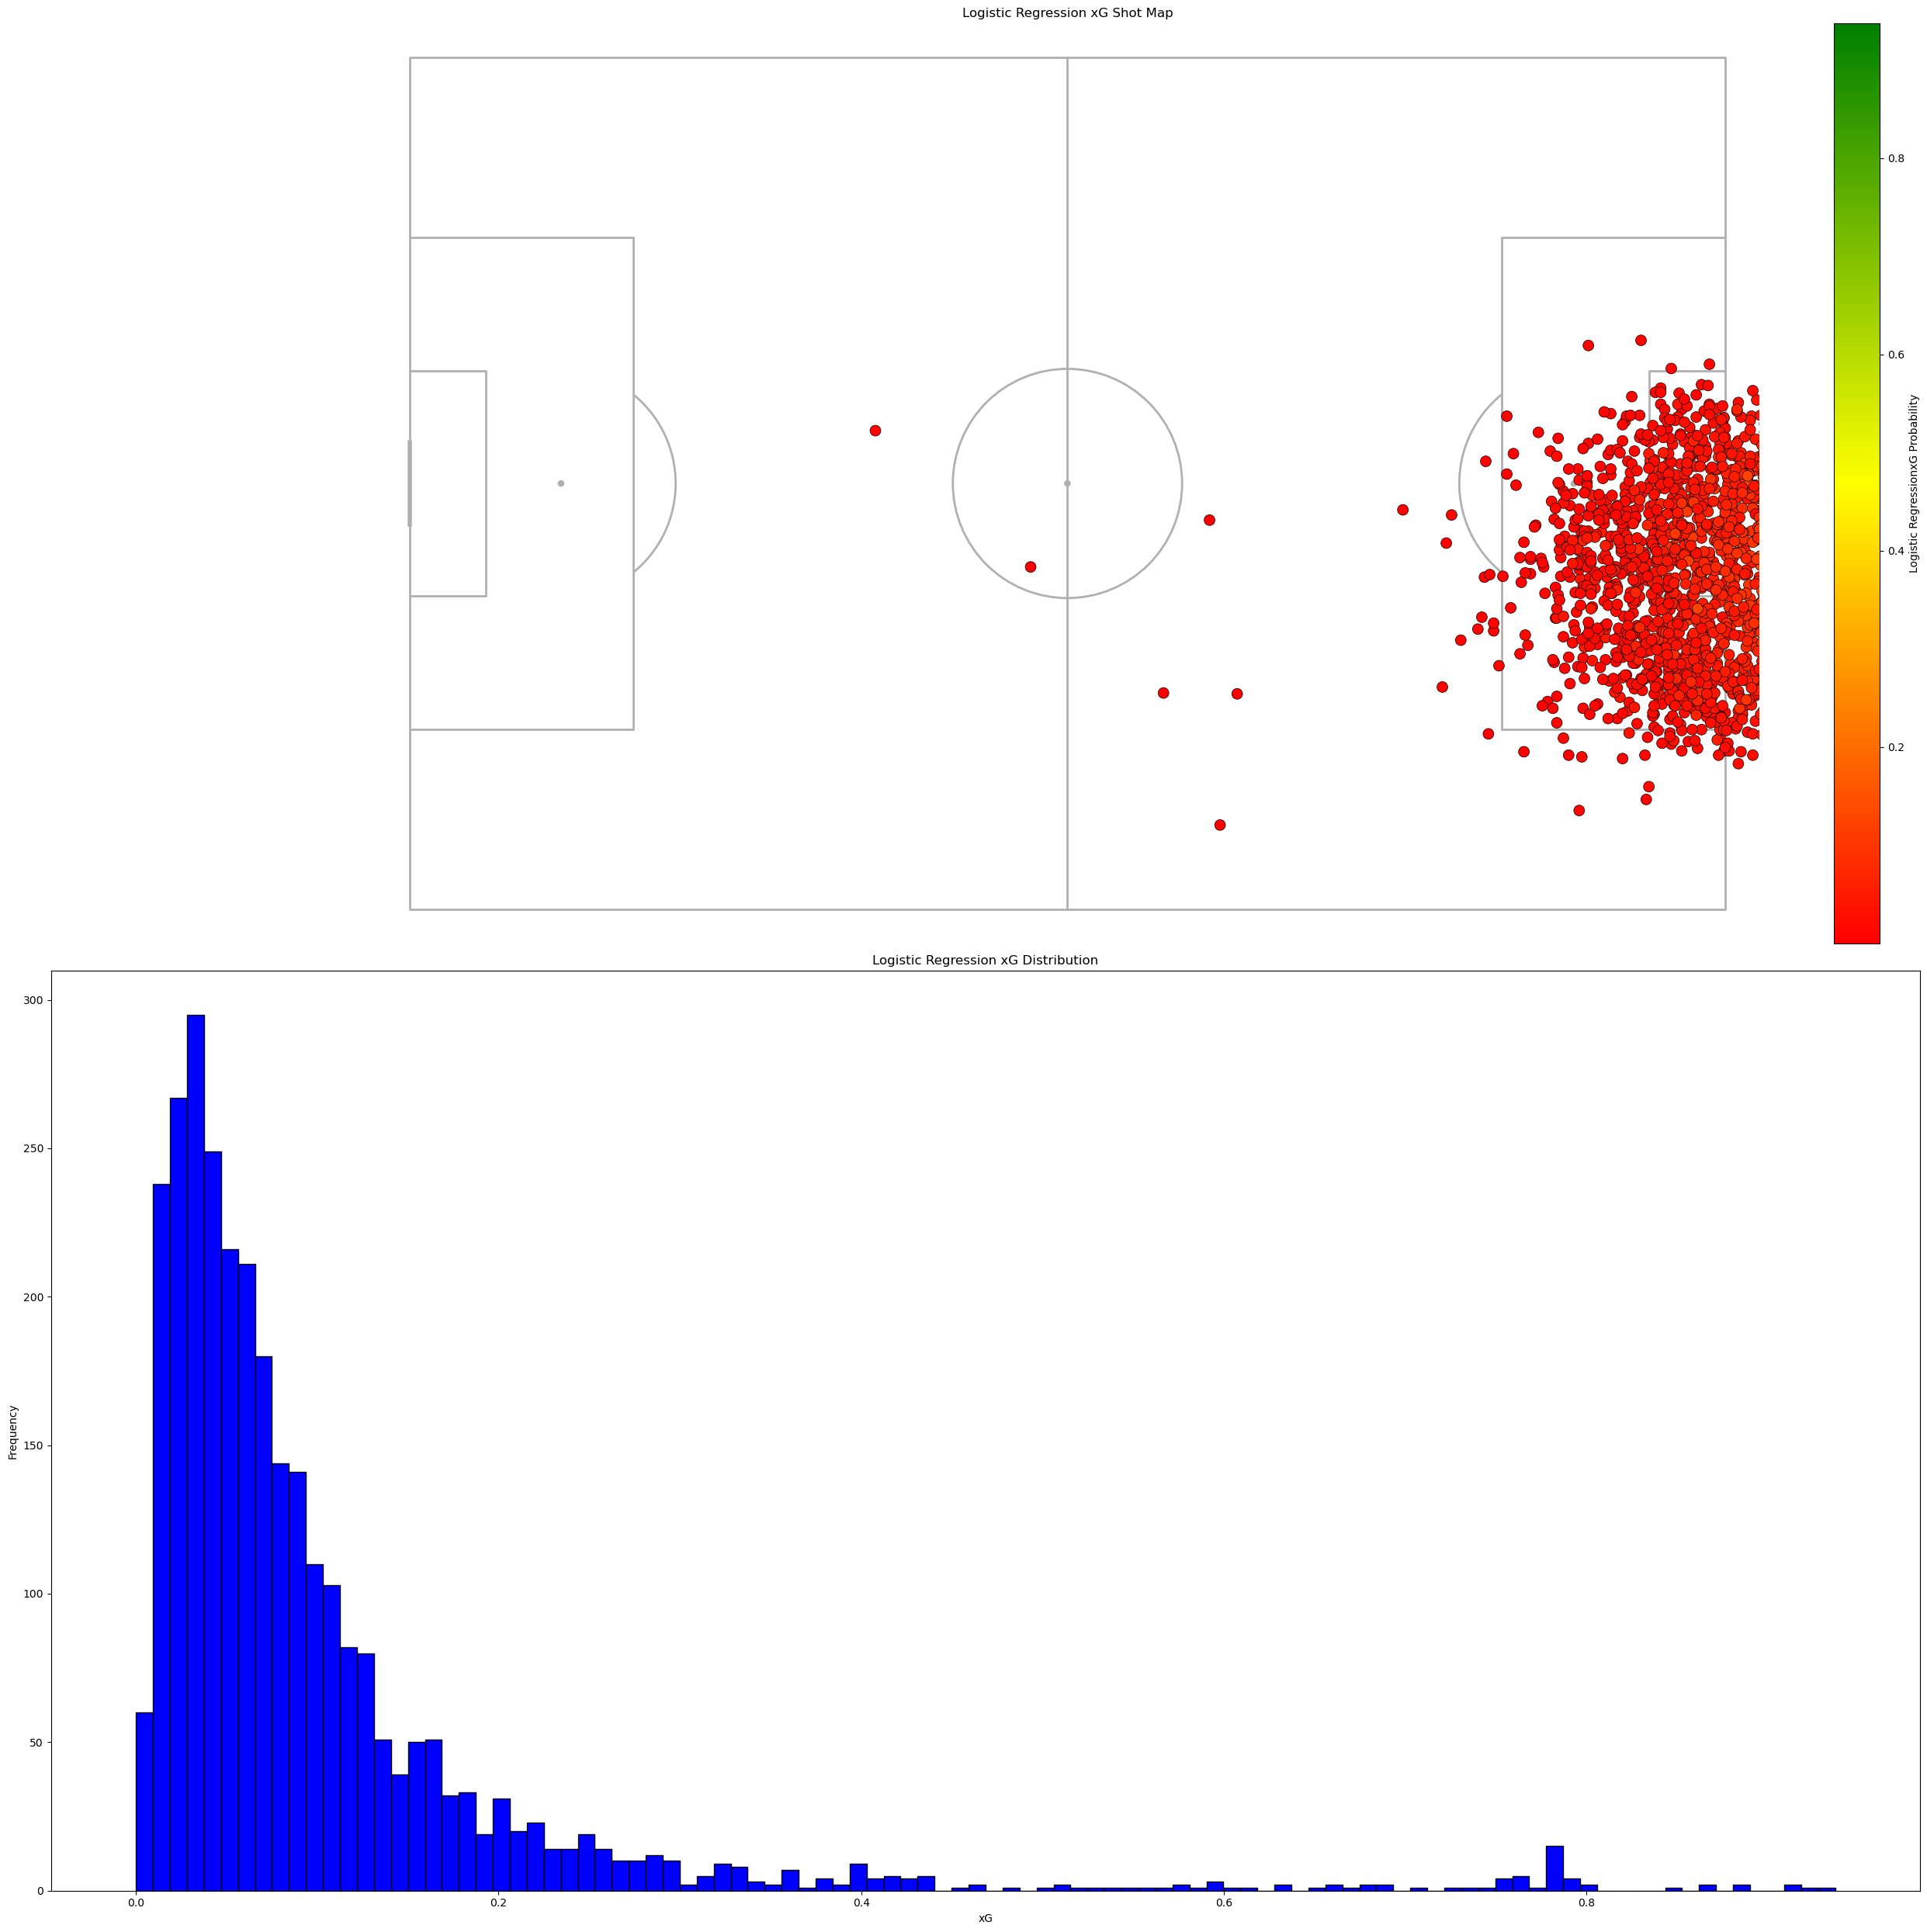

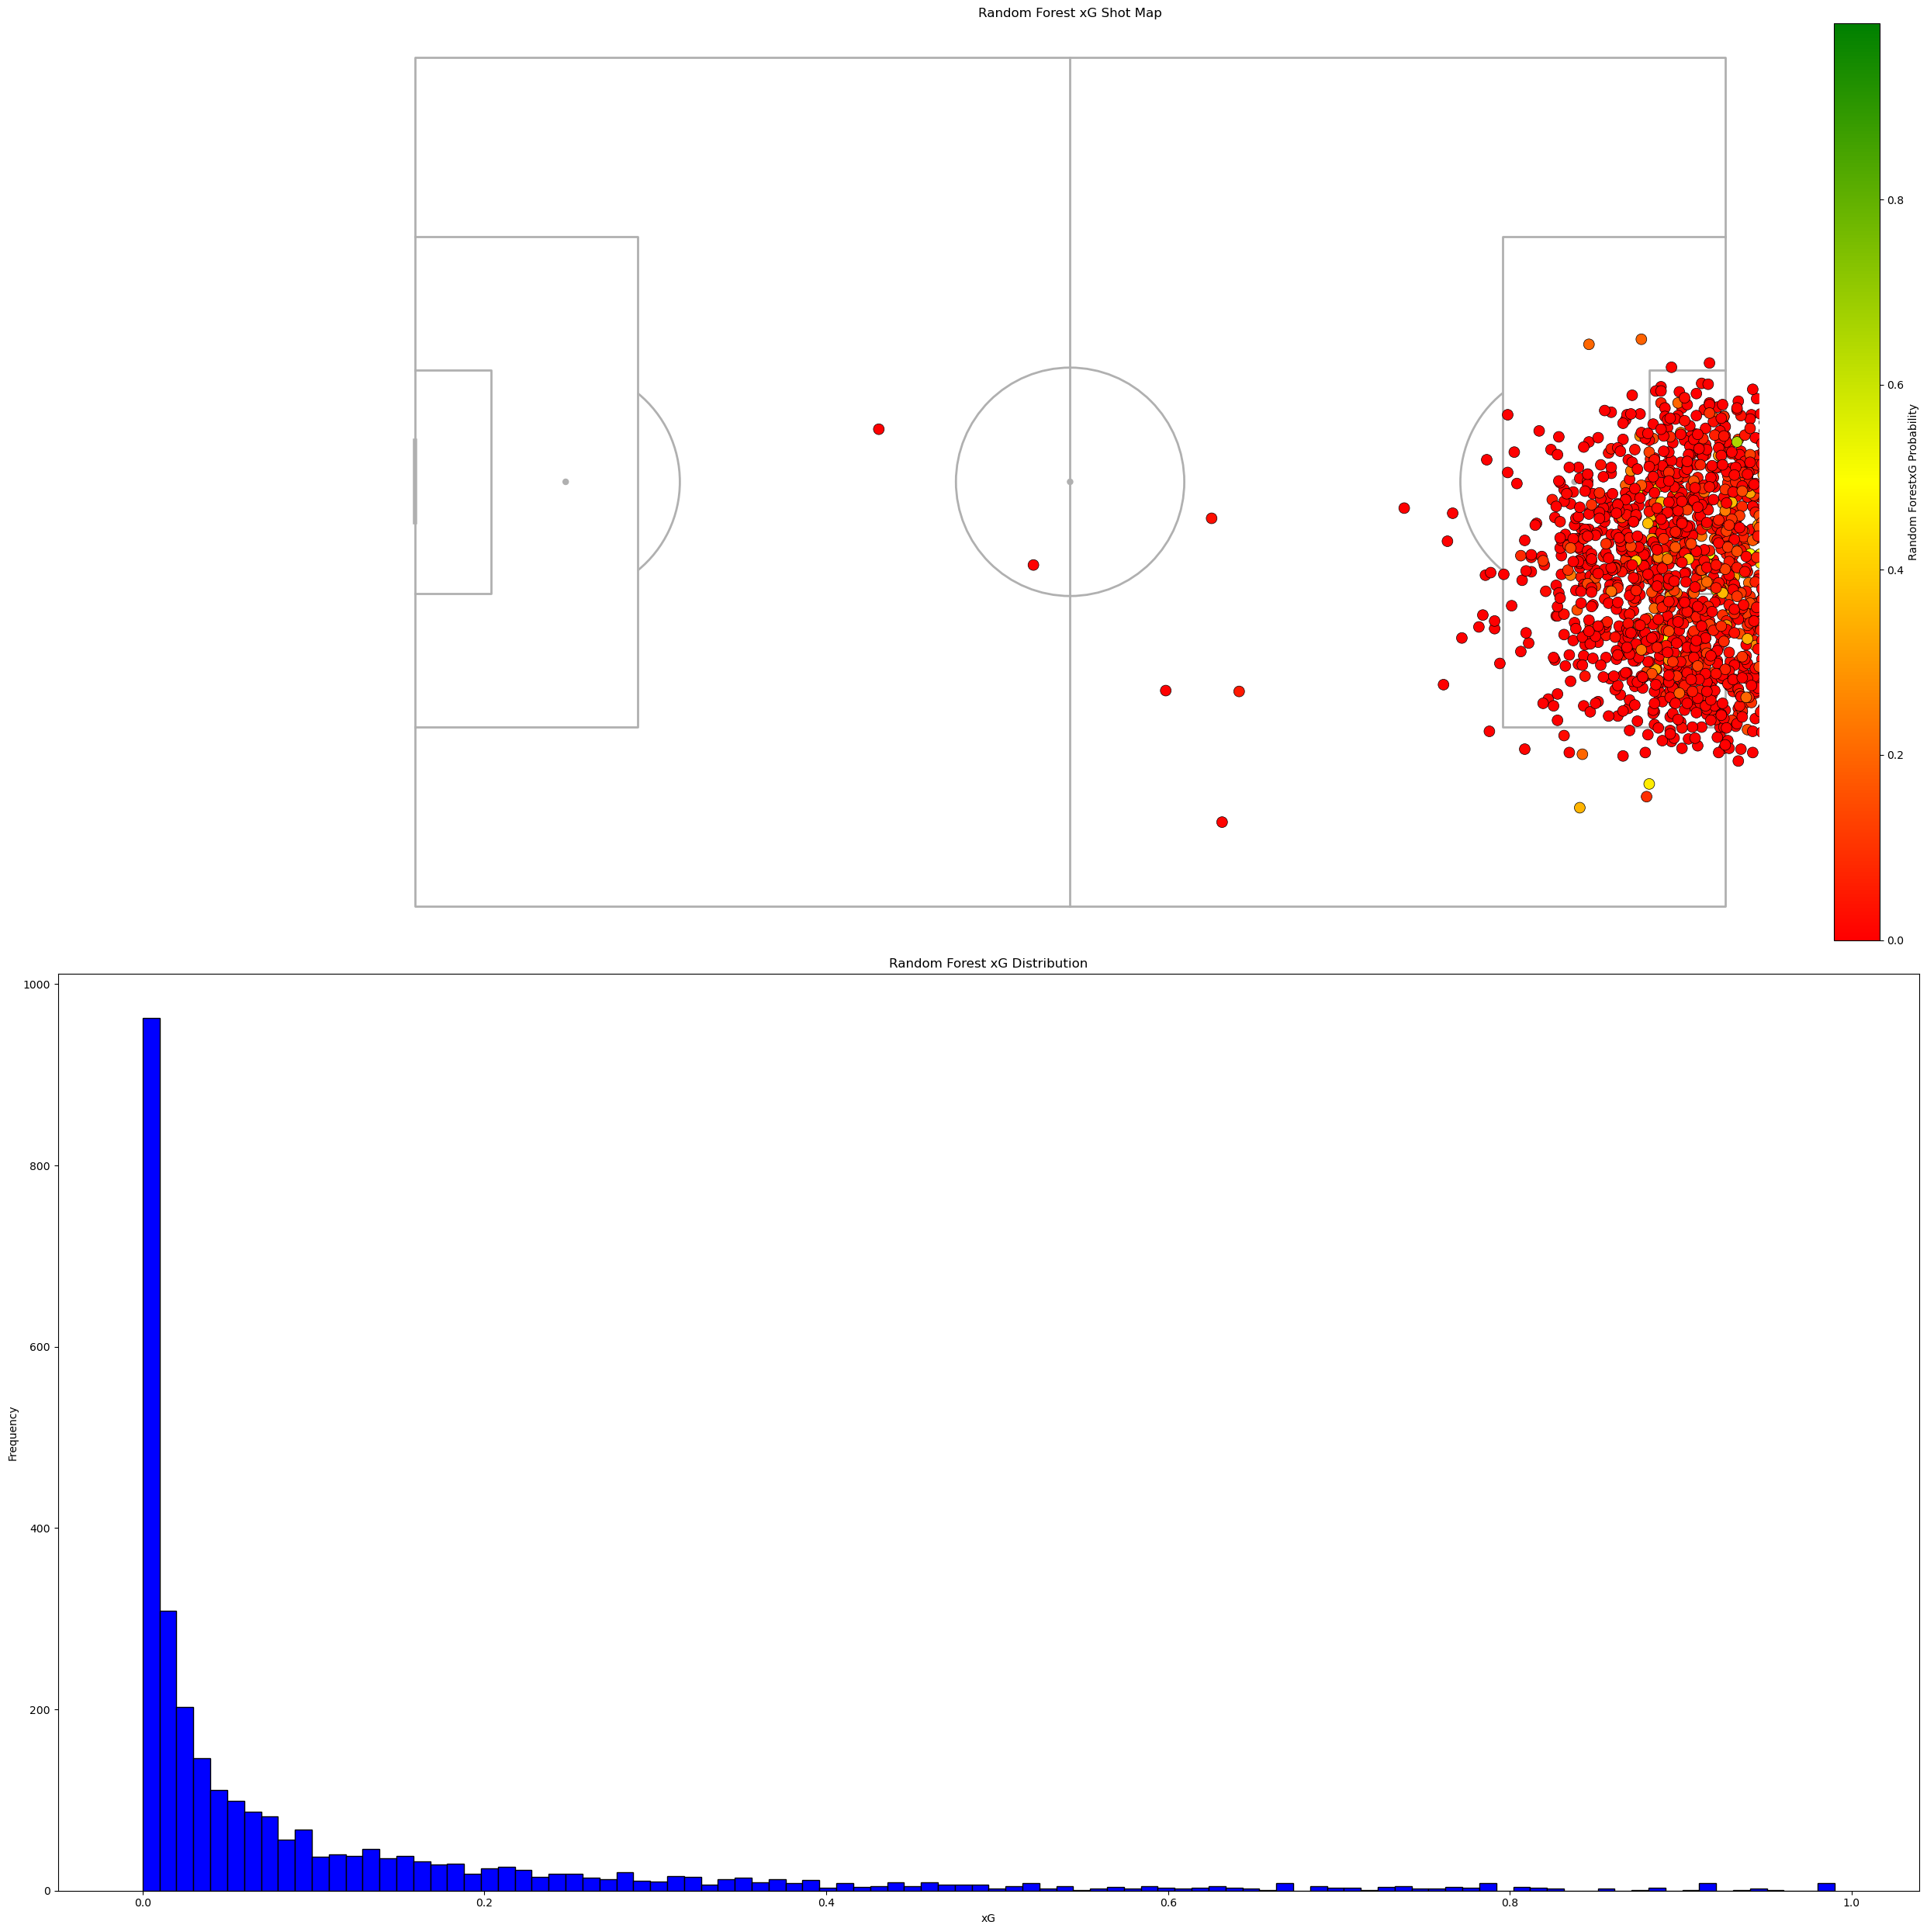

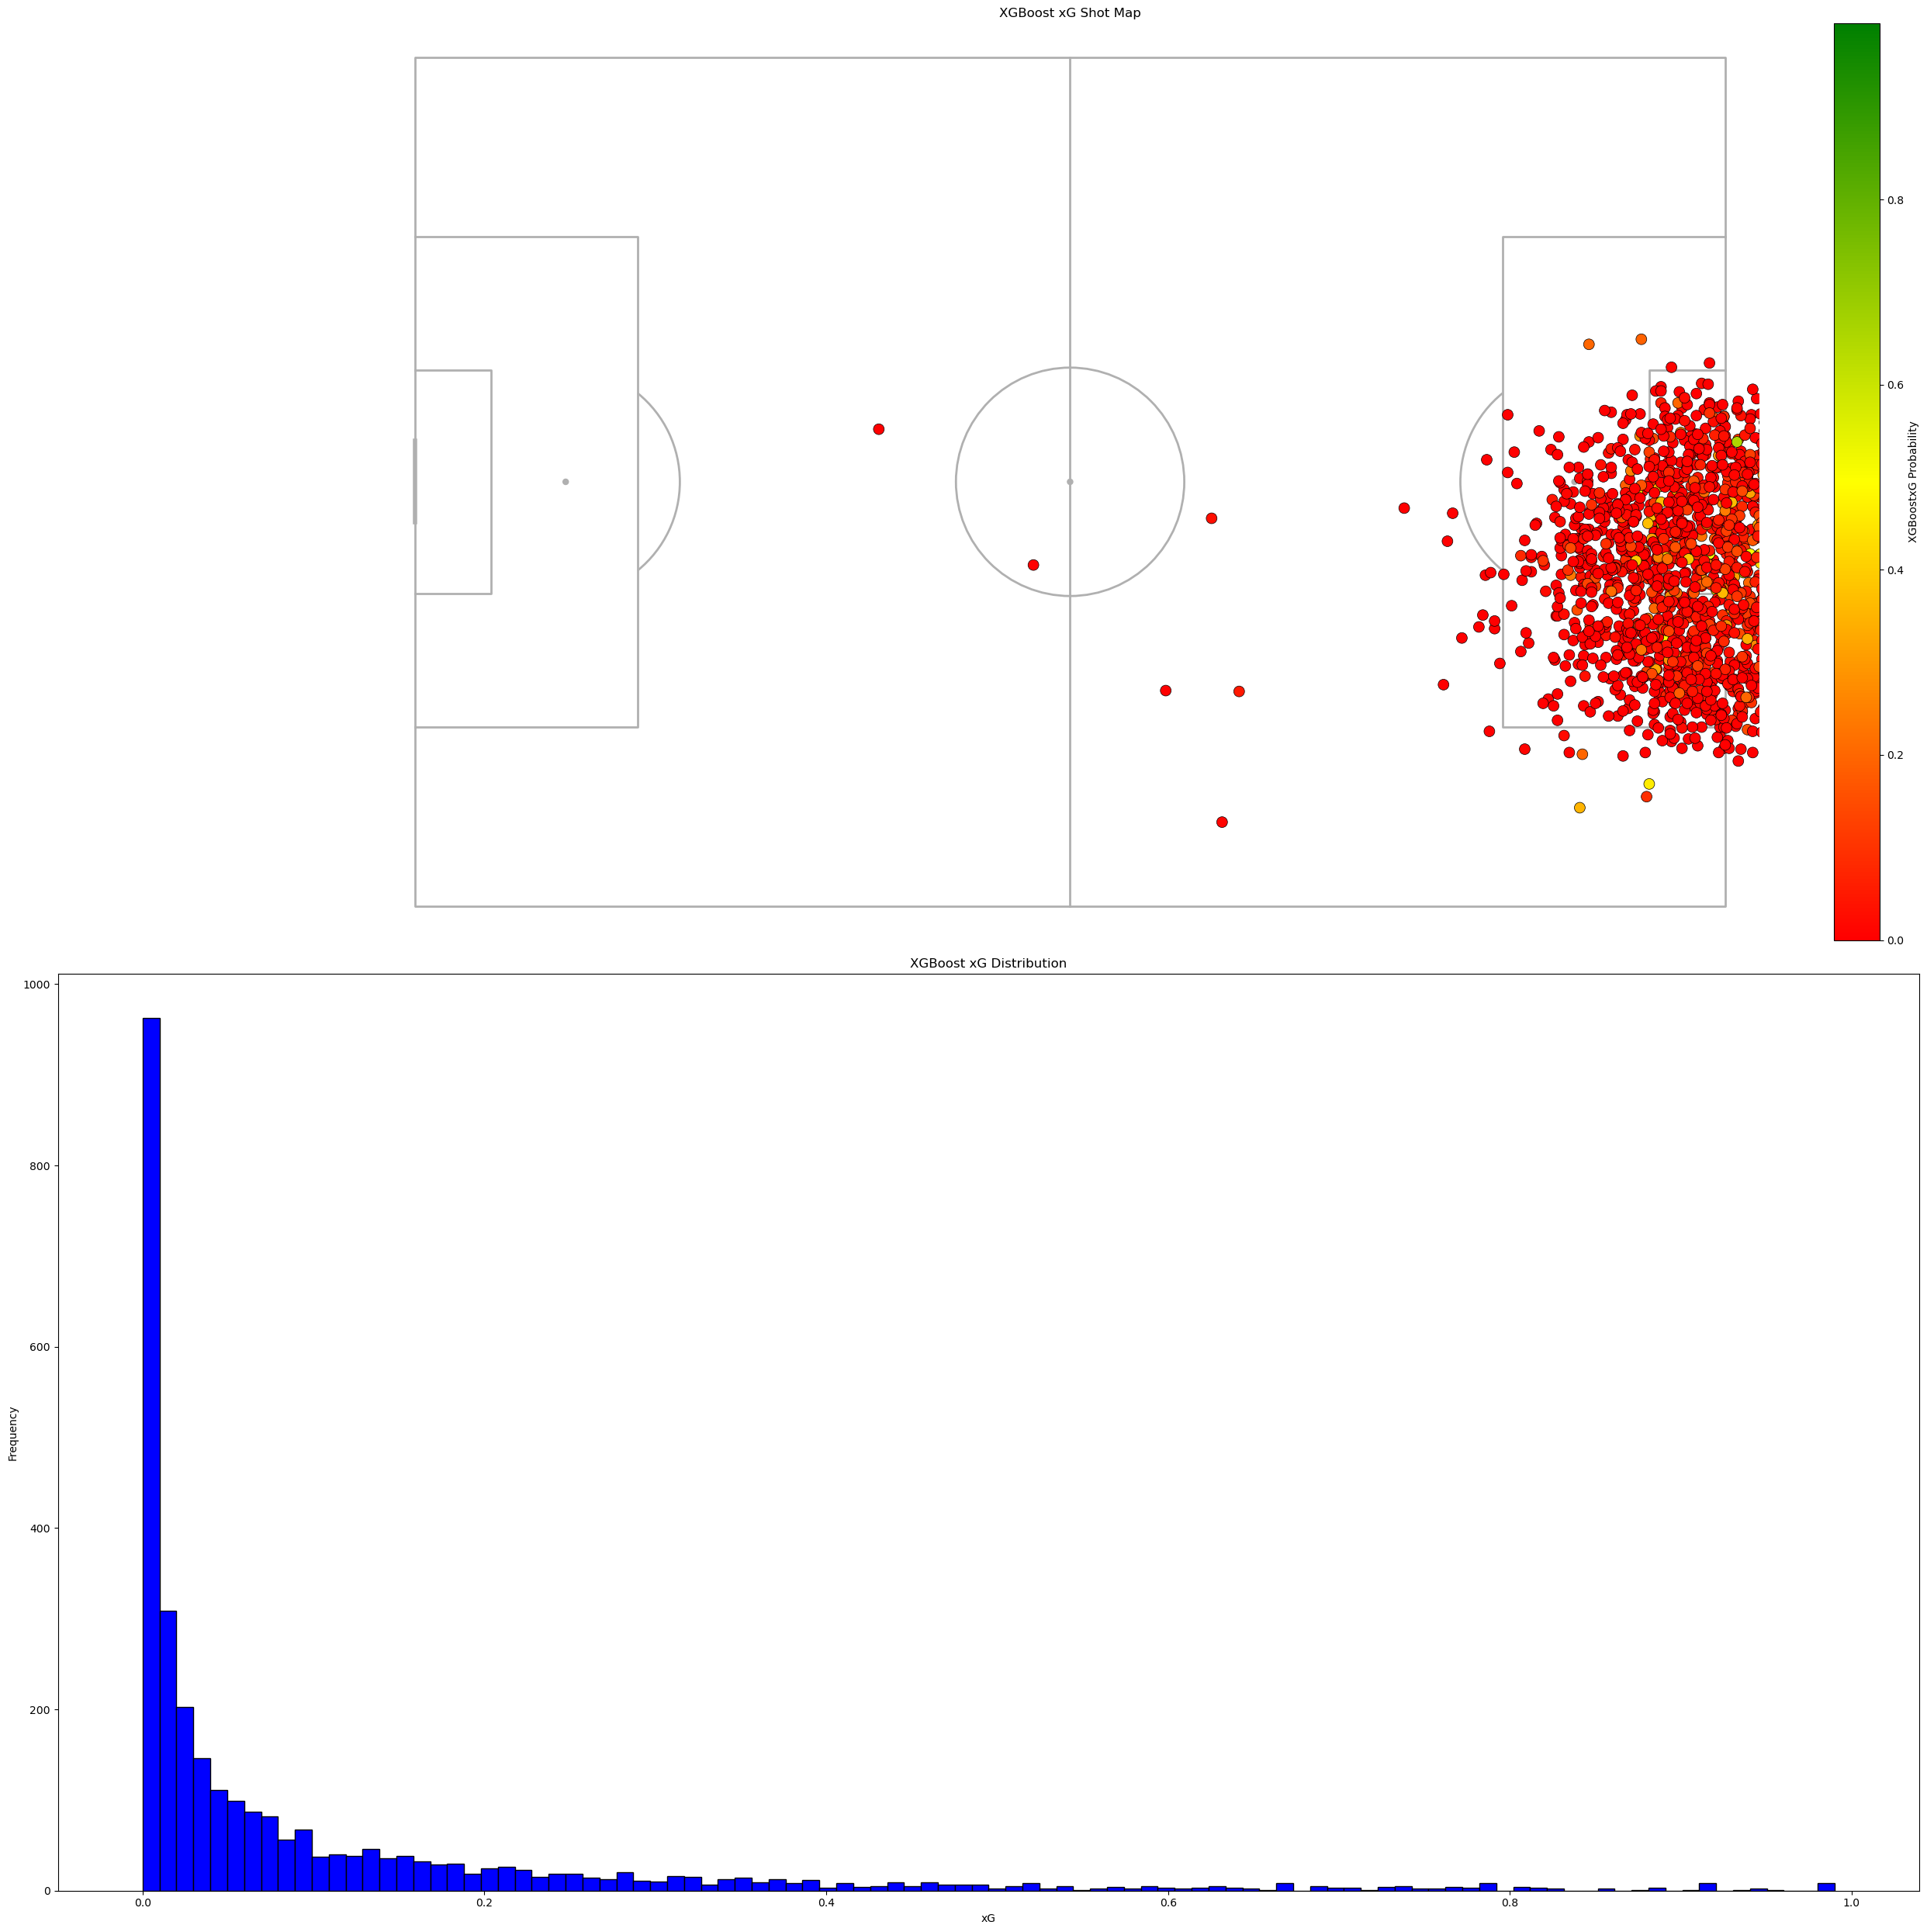

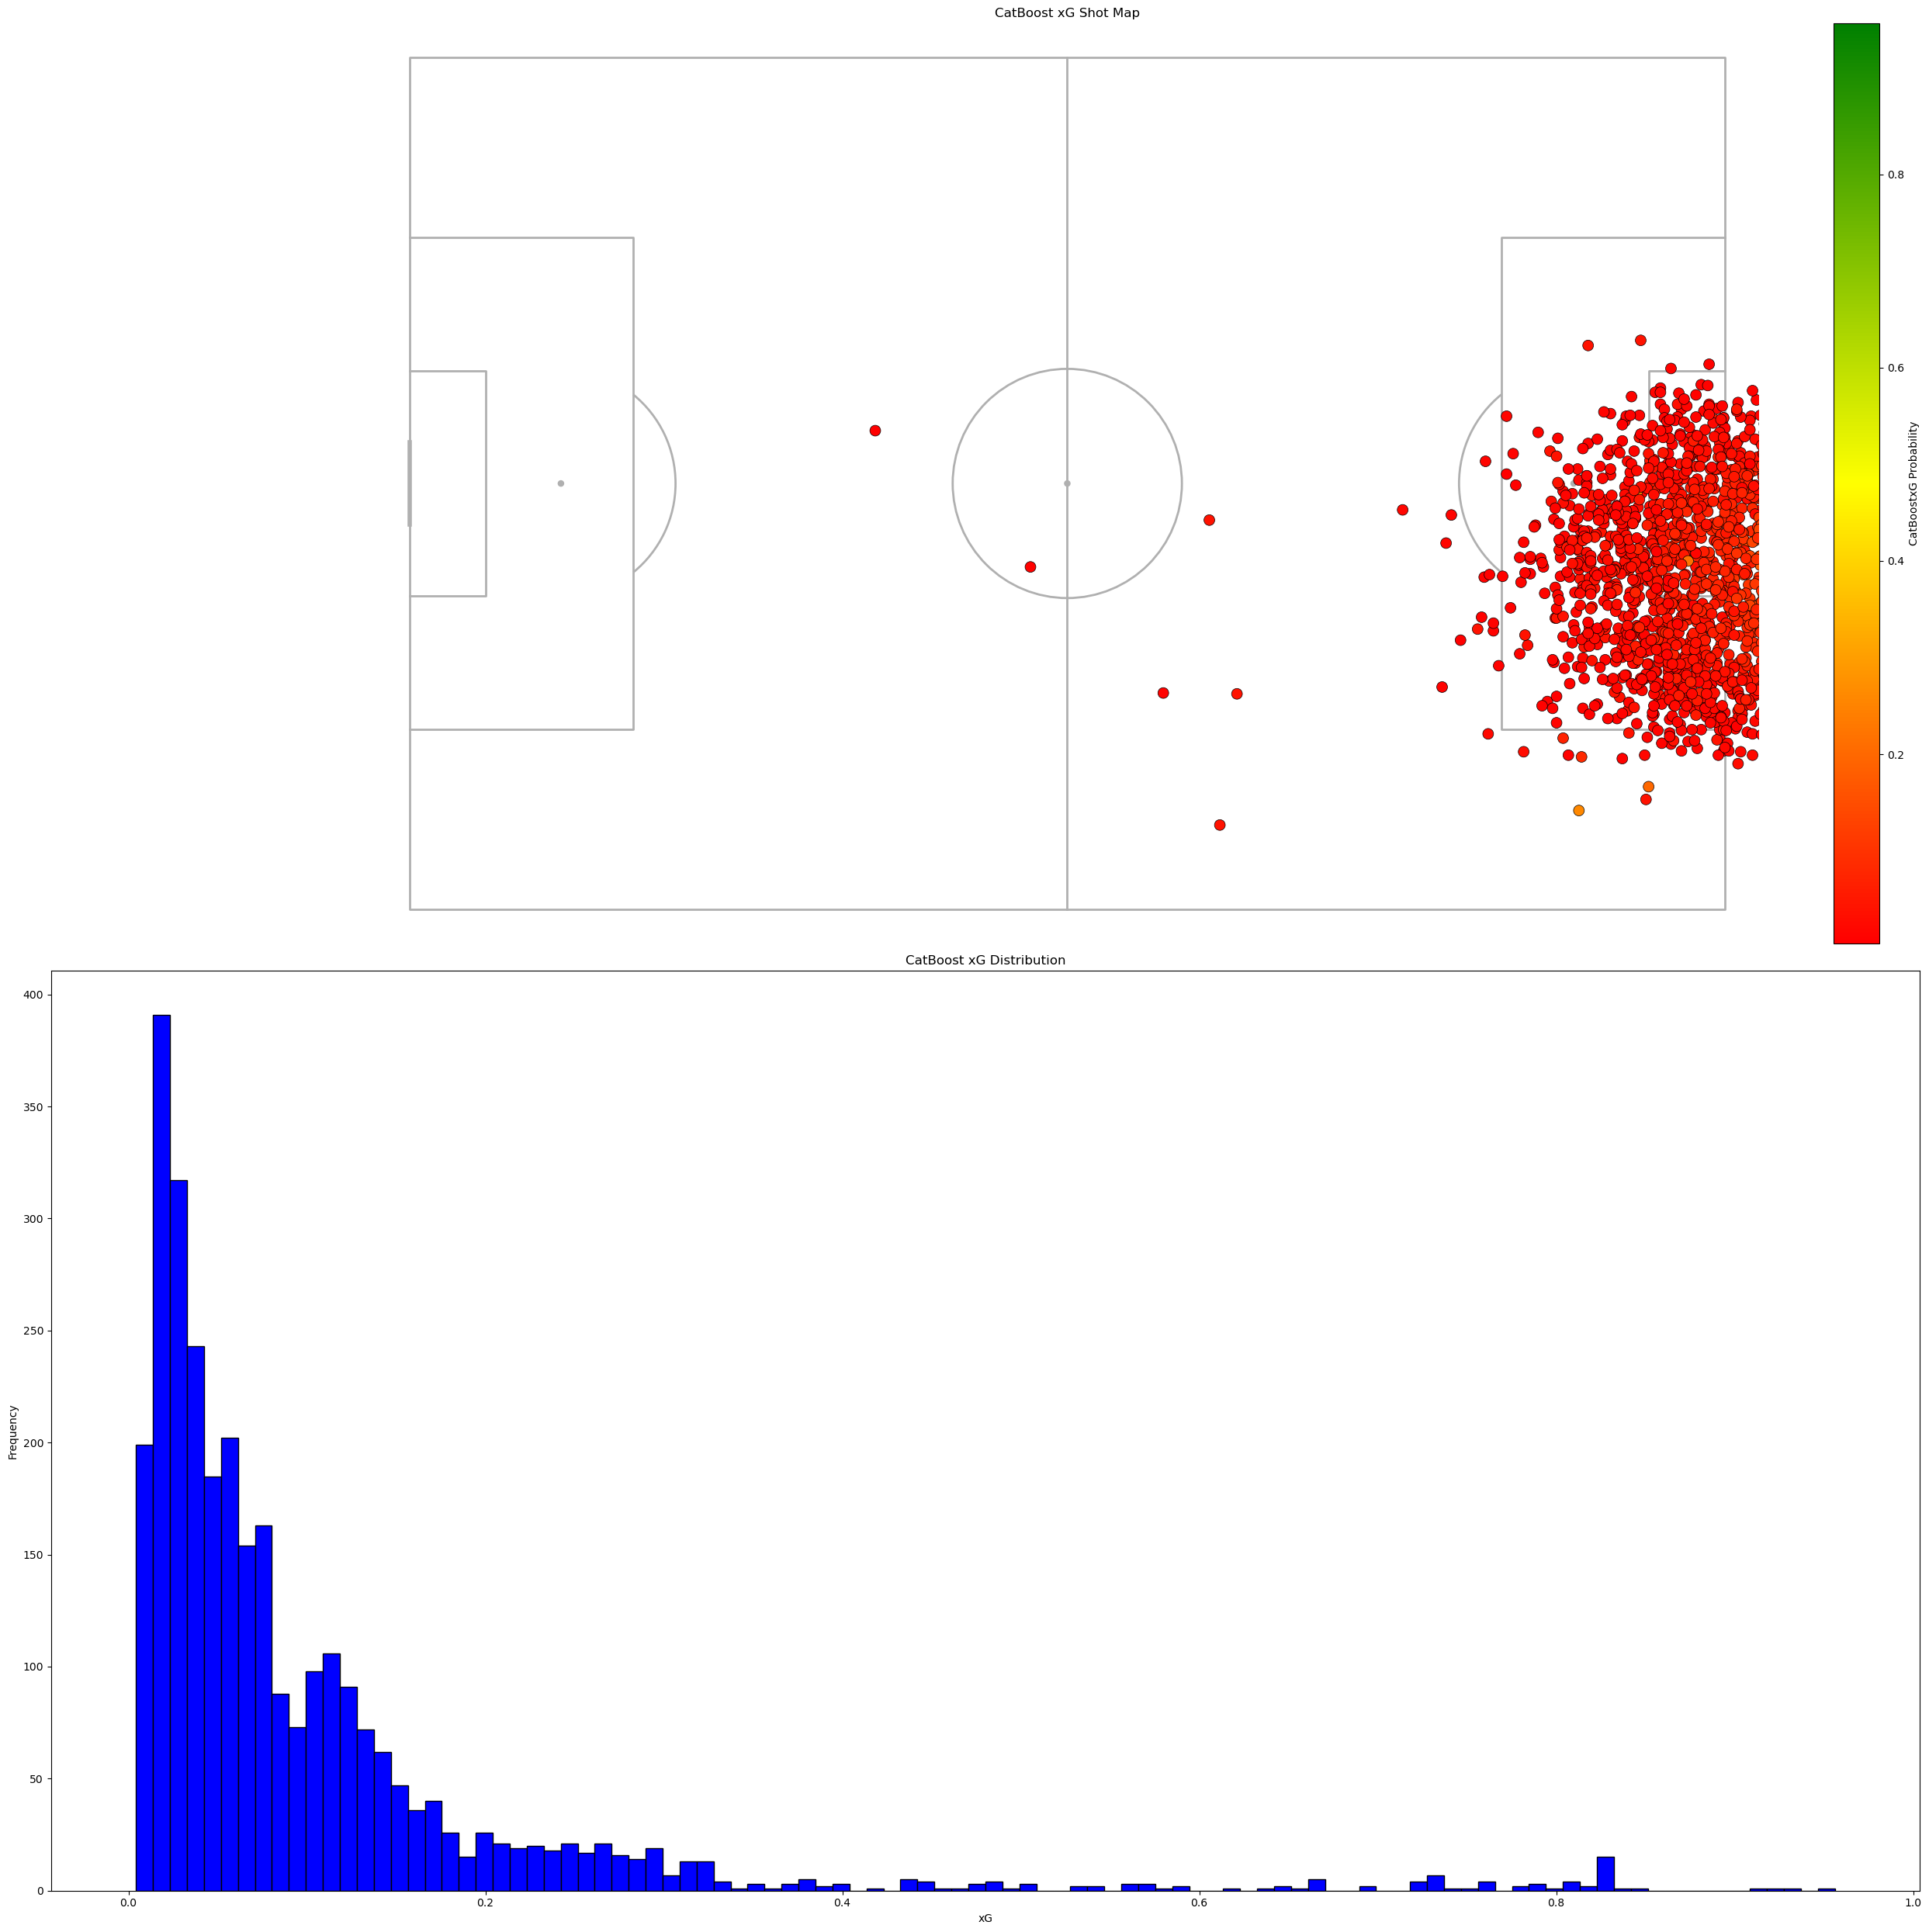

In [42]:
import matplotlib.pyplot as plt
import numpy as np

dataframes = {
    'Logistic Regression': log_df,
    'Random Forest': rf_df,
    'XGBoost': xgb_df,
    'CatBoost': cat_df
}

for name, df in dataframes.items():
    
    fig, axes = plt.subplots(2, 1, figsize=(25,25))

    # ---- TOP: Pitch Plot ----
    pitch.draw(ax=axes[0])
    
    sc = pitch.scatter(
        cordinates['x'], cordinates['y'],
        c=df['xG'],
        cmap=cmap,
        edgecolors='black',
        linewidth=0.5,
        s=100,
        ax=axes[0]
    )
    
    axes[0].set_title(f'{name} xG Shot Map')
    
    cbar = plt.colorbar(sc, ax=axes[0], fraction=0.046, pad=0.04)
    cbar.set_label(f'{name}xG Probability')
    
    # ---- BOTTOM: Histogram ----
    
    axes[1].hist(df['xG'], bins=100, color='blue', edgecolor='black')
    axes[1].set_title(f'{name} xG Distribution')
    axes[1].set_xlabel('xG')
    axes[1].set_ylabel('Frequency')
    
    
    plt.tight_layout()
    plt.show()